<a href="https://colab.research.google.com/github/kumarsirish/IIITB/blob/main/MLOps-Assignment/MLOps_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MLOps Assignment: Predictive Maintenance Classification
### Starter Notebook

**Domain:** Industrial IoT / Manufacturing
**Task:** Multi-class failure type prediction
**Tools:** Pandera ? MLflow ? Optuna ? Evidently ? SHAP

---

## Business Context

A heavy-equipment manufacturer runs 10,000+ machines on the shop floor.
Each machine continuously streams six sensor readings. When a machine fails,
production halts ? at a cost of ?8?15 lakh per hour of downtime.

Your job is to build a full MLOps pipeline that:
1. Validates incoming sensor data before it enters the pipeline (Pandera)
2. Trains and tracks a multi-class failure classifier (MLflow)
3. Tunes hyperparameters and registers the best model (Optuna + MLflow Registry)
4. Monitors the deployed model for distributional shift (Evidently)
5. Explains why the model predicts a specific failure type (SHAP)

**Files provided:**
- `data/train.csv`   ? 6,993 labelled sensor readings (historical baseline)
- `data/current.csv` ? 1,499 readings from the current stable production batch
- `data/stress.csv`  ? 1,499 readings from a heavy-load production period

**Failure classes:**

| Code | Name | Description |
|------|------|-------------|
| 0 | No Failure | Machine operating normally |
| 1 | TWF | Tool Wear Failure |
| 2 | HDF | Heat Dissipation Failure |
| 3 | PWF | Power Failure |
| 4 | OSF | Overstrain Failure |

> Visual anchor: use the generated `eda_distributions.png` early (Section 1.3) to ground your expectations before drift and SHAP interpretation.
> Stress-batch goal: diagnose *why* the model is stale under shifted operating conditions, not to force perfect predictions on `stress.csv`.
> **Submission:** Submit this notebook (`.ipynb`) with all cells executed.
> Do not change the section structure or remove any markdown cells.

## **1. Data Loading, Schema Validation & EDA** <font color=red>[15 marks]</font>

### **1.1** <font color=red>[3 marks]</font> Load the datasets

Load `train.csv`, `current.csv`, and `stress.csv` from the `data/` folder.
Print the shape of each and display the first 5 rows of the training set.


In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip install -r /content/drive/MyDrive/data/requirements.txt
!pip install mlflow

import mlflow



Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 130.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 92.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 121.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.9/386.9 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import os
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# TODO: Load the three datasets
#train   = pd.read_csv('data/train.csv')
#current = pd.read_csv('data/current.csv')
#stress  = pd.read_csv('data/stress.csv')
train   = pd.read_csv('/content/drive/MyDrive/data/train.csv')
current = pd.read_csv('/content/drive/MyDrive/data/current.csv')
stress  = pd.read_csv('/content/drive/MyDrive/data/stress.csv')

# TODO: Print shapes
print(f'train  : {train.shape}')
print(f'current: {current.shape}')
print(f'stress : {stress.shape}')

CLASS_NAMES = {0: 'No Failure', 1: 'TWF', 2: 'HDF', 3: 'PWF', 4: 'OSF'}
CLASS_DESCRIPTION = {0: 'Machine operating normally', 1: 'Tool Wear Failure', 2: 'Heat Dissipation Failure', 3: 'Power Failure', 4: 'Overstrain Failure'}

# TODO: Display first 5 rows of train
train.head()

### **1.2** <font color=red>[5 marks]</font> Define and apply a Pandera schema

Define a `DataFrameSchema` enforcing the domain constraints below.
Validate `train` and `current` (must pass). Validate `stress` with `lazy=True`.

| Column | Type | Constraint |
|--------|------|------------|
| Type | str | one of L, M, H |
| Air temperature | float | [295.0, 305.0] K |
| Process temperature | float | [305.0, 315.0] K |
| Rotational speed | int64 | [1000, 2900] rpm |
| Torque | float | [3.0, 80.0] Nm |
| Tool wear | int64 | [0, 253] min |
| Failure_Type | int64 | 0, 1, 2, 3, 4 |


> `stress.csv` may still pass schema validation. That is fine: it is designed to be valid but drifted.
> Hint: valid data can still be statistically unusual. Before Section 3, compare the mean of `Rotational speed` in `current` vs `stress`.

In [3]:
# !pip install pandera
import pandera as pa
from pandera import Column, DataFrameSchema, Check

# TODO: Define the schema
schema = DataFrameSchema({
    # fill in each column constraint
    "Rotational speed": Column(int, checks=[Check.in_range(1000, 2900)]),
    "Type" : Column(str, checks=[Check.isin(['L', 'M', 'H'])]),
    "Tool wear": Column(int, checks=[Check.in_range(0, 253)]),
    "Failure_Type": Column(int, checks=[Check.isin([0, 1, 2, 3, 4])]),
    "Torque": Column(float, checks=[Check.in_range(3.0, 80.0)]),
    "Process temperature": Column(float, checks=[Check.in_range(305.0, 315.0)]),
    "Air temperature": Column(float, checks=[Check.in_range(295.0, 305.0)]),
})

def fix_dtypes(df):
    df = df.copy()
    df['Rotational speed'] = df['Rotational speed'].astype('int64')
    df['Tool wear']        = df['Tool wear'].astype('int64')
    df['Failure_Type']     = df['Failure_Type'].astype('int64')
    return df

train   = fix_dtypes(train)
current = fix_dtypes(current)
stress  = fix_dtypes(stress)

# TODO: Validate train and current
schema.validate(train)
schema.validate(current)

# TODO: Validate stress with lazy=True and print violation summary
schema.validate(stress, lazy=True)


,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Failure_Type
0,L,301.0,310.9,1523,44.3,93,0
1,M,297.3,308.4,1473,44.4,126,0
2,M,299.0,310.0,1320,63.1,171,0
3,M,304.3,313.3,1503,42.8,66,0
4,L,298.4,309.5,1313,55.1,163,0
...,...,...,...,...,...,...,...
1494,L,302.2,311.5,1440,45.1,145,0
1495,M,295.6,306.1,1608,31.7,166,0
1496,L,303.3,312.5,1905,25.7,186,0
1497,L,298.8,310.1,1499,41.6,231,0


### **1.3** <font color=red>[4 marks]</font> Exploratory Data Analysis

1. Print the class distribution of `Failure_Type`. Is it balanced?
2. Plot the distribution of `Torque` and `Tool wear` split by failure class (failures only).
3. Print the `Type` (L/M/H) distribution.


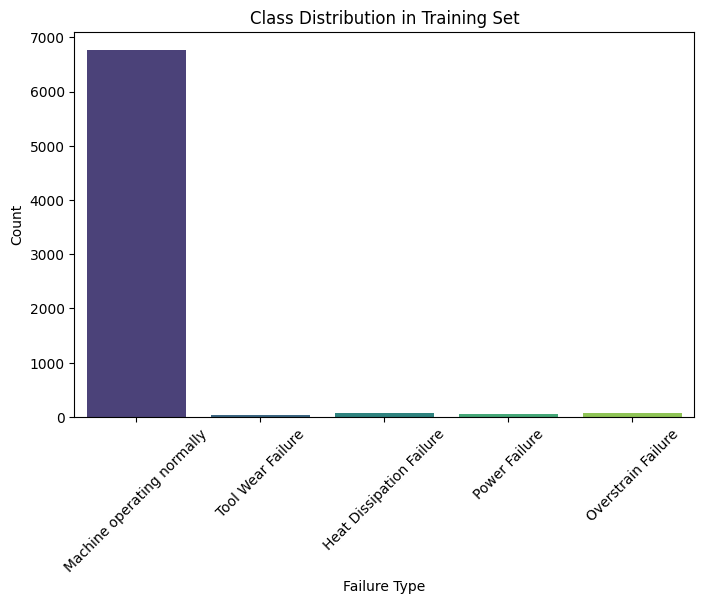

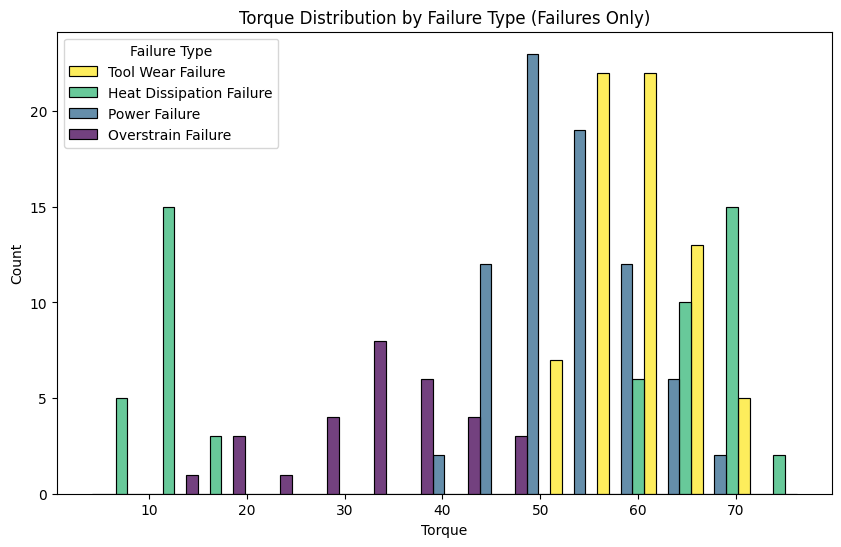

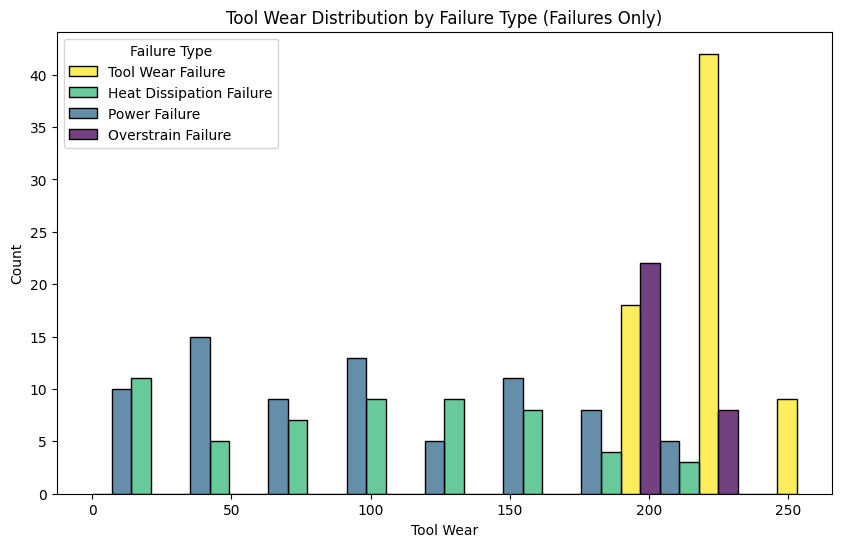

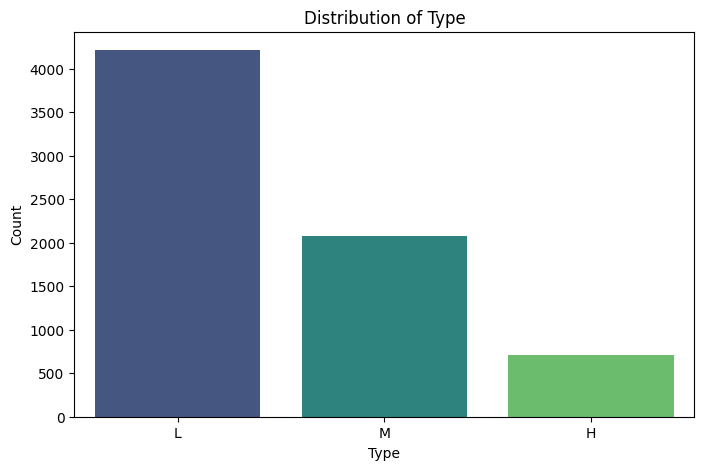

In [14]:
# TODO: Class distribution (print + bar chart)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(x='Failure_Type', data=train, palette='viridis')
plt.title('Class Distribution in Training Set')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=[CLASS_DESCRIPTION[i] for i in range(5)], rotation=45)
plt.show()
# TODO: Torque distribution by failure type (histogram, failures only)
plt.figure(figsize=(10, 6))


sns.histplot(
    data=train[train['Failure_Type'] != 0],
    x='Torque',
    hue='Failure_Type',
    multiple='dodge',   # or 'layer'
    element='bars',     # or 'step'
    palette='viridis'
)
plt.title('Torque Distribution by Failure Type (Failures Only)')
plt.xlabel('Torque')
plt.ylabel('Count')
plt.legend(title='Failure Type', labels=[CLASS_DESCRIPTION[i] for i in range(1, 5)])
plt.show()

# TODO: Tool wear distribution by failure type
plt.figure(figsize=(10, 6))
sns.histplot(
    data=train[train['Failure_Type'] != 0],
    x='Tool wear',
    hue='Failure_Type',
    multiple='dodge',   # or 'layer'
    element='bars',     # or 'step'
    palette='viridis'
)
plt.title('Tool Wear Distribution by Failure Type (Failures Only)')
plt.xlabel('Tool Wear')
plt.ylabel('Count')
plt.legend(title='Failure Type', labels=[CLASS_DESCRIPTION[i] for i in range(1, 5)])
plt.show()

# TODO: Type distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='Type', data=train, palette='viridis')
plt.title('Distribution of Type')
plt.xlabel('Type')
plt.ylabel('Count')
plt.savefig('eda_distributions.png')
plt.show()



### **1.4** <font color=red>[3 marks]</font> Feature Engineering

Compute the following derived features for all three datasets:

**Mechanical power** (Watts):
$$P = \text{Torque} \times \frac{\text{Rotational speed} \times 2\pi}{60}$$

**Temperature differential**:
$$\Delta T = \text{Process temperature} - \text{Air temperature}$$

Print the mean of each new feature grouped by `Failure_Type`.


In [5]:
def engineer_features(df):
    df = df.copy()
    # TODO: Compute Power_W
    df['Power_W'] = (df['Torque'] * df['Rotational speed'] * 2 * np.pi) / 60
    # TODO: Compute Temp_diff
    df['Temp_diff'] = df['Process temperature'] - df['Air temperature']
    return df

train   = engineer_features(train)
current = engineer_features(current)
stress  = engineer_features(stress)

# TODO: Print grouped mean
grouped_means = train.groupby('Failure_Type')[['Power_W', 'Temp_diff']].mean()
print(grouped_means)

print(train.head())


                  Power_W  Temp_diff
Failure_Type                        
0             6248.240886  10.013812
1             5763.094643   9.966667
2             7403.545453   8.228947
3             6664.382233   9.823214
4             8216.074774  10.072464
  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    L            302.5                311.1              1499    38.8   
1    L            297.3                308.4              1469    46.7   
2    L            297.3                308.5              1504    42.0   
3    L            299.6                309.5              1803    27.7   
4    L            301.1                311.1              1387    53.1   

   Tool wear  Failure_Type      Power_W  Temp_diff  
0        135             0  6090.626621        8.6  
1         65             0  7184.016057       11.1  
2        142             0  6614.937491       11.2  
3        159             0  5230.029202        9.9  
4        188             0  771

## **2. Experiment Tracking & Model Selection** <font color=red>[15 marks]</font>

### **2.1** <font color=red>[2 marks]</font> Setup: features, split, SMOTE

Use the features below. Apply a stratified 80/20 train-val split (random_state=42).
Apply SMOTE to the training split only. Print the post-SMOTE class distribution.

```
FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
```

> In a markdown cell below the code, explain in 2–3 sentences why SMOTE is applied
> only to the training split and not the validation set.


  Type  Air temperature  Process temperature  Rotational speed  Torque  \
0    L            302.5                311.1              1499    38.8   
1    L            297.3                308.4              1469    46.7   
2    L            297.3                308.5              1504    42.0   
3    L            299.6                309.5              1803    27.7   
4    L            301.1                311.1              1387    53.1   

   Tool wear  Failure_Type      Power_W  Temp_diff  Type_enc  
0        135             0  6090.626621        8.6         1  
1         65             0  7184.016057       11.1         1  
2        142             0  6614.937491       11.2         1  
3        159             0  5230.029202        9.9         1  
4        188             0  7712.578549       10.0         1  
Post-SMOTE class distribution:
Failure_Type
0    5409
3    5409
4    5409
2    5409
1    5409
Name: count, dtype: int64


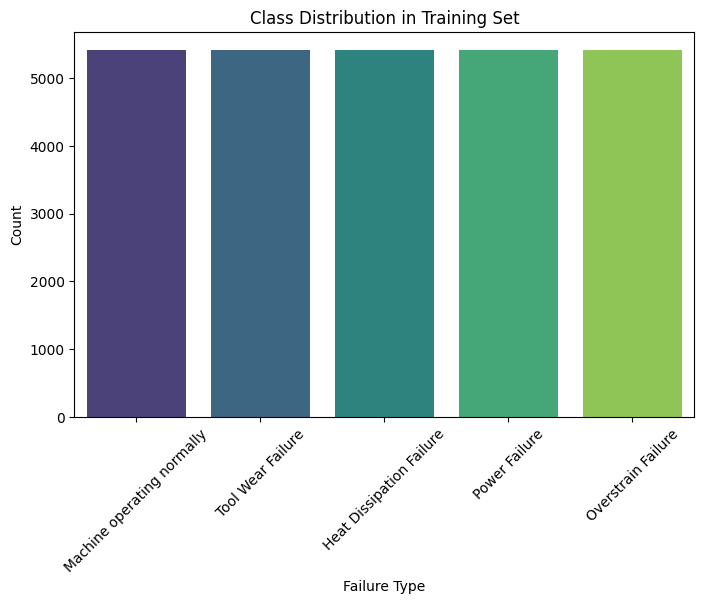

In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# TODO: Encode "Type" column values L/M/H
le = LabelEncoder()
train['Type_enc']   = le.fit_transform(train['Type'])
current['Type_enc'] = le.transform(current['Type'])
stress['Type_enc']  = le.transform(stress['Type'])

FEATURES = ['Type_enc', 'Air temperature', 'Process temperature',
            'Rotational speed', 'Torque', 'Tool wear', 'Power_W', 'Temp_diff']
print(train.head())
# TODO: Define X and y
X = train[FEATURES]
y = train['Failure_Type']
# TODO: Train-val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
# TODO: Apply SMOTE (k_neighbors=3, random_state=42)
smote = SMOTE(k_neighbors=3, random_state=42)
X_train_augmented, y_train_augmented = smote.fit_resample(X_train, y_train)
# TODO: Print post-SMOTE class distribution
print("Post-SMOTE class distribution:")
print(y_train_augmented.value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(x=y_train_augmented, palette='viridis')
plt.title('Class Distribution in Training Set')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2, 3, 4], labels=[CLASS_DESCRIPTION[i] for i in range(5)], rotation=45)
plt.show()

*Your explanation here: why is SMOTE applied only on the training split?*
### Answer
SMOTE is applied only to the training split so the model can learn from a more balanced class distribution. The validation set must remain untouched and representative of real-world data, otherwise the evaluation metrics would be overly unreliable. Applying SMOTE to validation data would introduce synthetic samples into testing and distort true model performance.

### **2.2** <font color=red>[8 marks]</font> Train and log 4 models with MLflow

Train and evaluate:
- Logistic Regression
- Random Forest (n_estimators=100)
- XGBoost (n_estimators=100)
- LightGBM (n_estimators=100)

MLflow experiment name: `PredMaint_ModelSelection`

For each run log: `model` (param), `macro_f1`, `weighted_f1`, `accuracy` (metrics),
and per-class F1 for all 5 classes. Print a comparison table. Pick the best model by macro F1.


### **2.3** <font color=red>[5 marks]</font> Optuna tuning + MLflow Model Registry

Run an Optuna study (30 trials, `TPESampler(seed=42)`) tuning XGBoost hyperparameters.
Optimise for `macro_f1` on `X_val`.

MLflow experiment: `PredMaint_Optuna`

Register the best model as `PredMaint_XGBoost` and promote it to the `production` alias.
Print the improvement in macro F1 over the baseline XGBoost.


In [7]:
import mlflow
import mlflow.sklearn
import pandas as pd
from sklearn.metrics import f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import mlflow

mlflow.set_experiment('PredMaint_ModelSelection')

CLASS_LIST = [0, 1, 2, 3, 4]
results = []
models_to_run = {
    'LogisticRegression': Pipeline(
        [(
            'scaler', StandardScaler()
        ),
        (
            'lr', LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
        ),
    ]),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=100, random_state=42, class_weight='balanced', verbose=-1),
}

# Train, evaluate, and log all models
for model_name, model in models_to_run.items():
    with mlflow.start_run(run_name=model_name):
        model.fit(X_train_augmented, y_train_augmented)
        y_pred = model.predict(X_val)

        macro_f1 = f1_score(y_val, y_pred, average='macro', labels=CLASS_LIST)
        weighted_f1 = f1_score(y_val, y_pred, average='weighted', labels=CLASS_LIST)
        accuracy = accuracy_score(y_val, y_pred)
        per_class_f1 = f1_score(y_val, y_pred, average=None, labels=CLASS_LIST)

        mlflow.log_param('model', model_name)
        mlflow.log_metric('macro_f1', macro_f1)
        mlflow.log_metric('weighted_f1', weighted_f1)
        mlflow.log_metric('accuracy', accuracy)

        for i, class_label in enumerate(CLASS_LIST):
            mlflow.log_metric(f'f1_class_{class_label}', float(per_class_f1[i]))

        # NOTE: artifact_path is the correct argument name

        mlflow.sklearn.log_model(sk_model=model, name=model_name, input_example=X_val.iloc[:5])
        results.append({
            'run_name': model_name,
            'macro_f1': macro_f1,
            'weighted_f1': weighted_f1,
            'accuracy': accuracy,
        })

# Print comparison table
comparison_table = pd.DataFrame(results).sort_values('macro_f1', ascending=False).reset_index(drop=True)
print(comparison_table)

# Identify best model by macro F1
best_model = comparison_table.iloc[0]
print(f"Best model by macro F1: {best_model['run_name']} with macro F1: {best_model['macro_f1']:.4f}")

2026/05/03 09:53:01 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/03 09:53:01 INFO mlflow.store.db.utils: Updating database tables
2026/05/03 09:53:02 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_ModelSelection' does not exist. Creating a new experiment.
2026/05/03 09:53:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/05/03 09:53:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative

             run_name  macro_f1  weighted_f1  accuracy
0             XGBoost  0.748062     0.985147  0.984274
1        RandomForest  0.735542     0.985459  0.984989
2            LightGBM  0.729645     0.985088  0.984274
3  LogisticRegression  0.531231     0.932771  0.904217
Best model by macro F1: XGBoost with macro F1: 0.7481


In [8]:
import optuna
import joblib
import torch

optuna.logging.set_verbosity(optuna.logging.WARNING)

mlflow.set_experiment('PredMaint_Optuna')
tuned_model_name = 'PredMaint_XGBoost'

def get_xgb_device():
  if torch.cuda.is_available():
    device = torch.device('cuda')
  else:
    device = torch.device('cpu')
  return device

device = get_xgb_device()
print(f'Using device: {device}')

#hyperparameters in XGBoost
def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
        'max_depth':         trial.suggest_int('max_depth', 3, 10),
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight':  trial.suggest_float('min_child_weight', 1.0, 10.0),
        'subsample':         trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'gamma':             trial.suggest_float('gamma', 0.0, 2.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 5.0, log=True),
        'random_state': 42, 'eval_metric': 'mlogloss', 'verbosity': 0,
        #GPU params
        'device': str(device),
        'tree_method': 'hist' #works for both cpu and gpu in XGBoost
    }
    # TODO: Train XGBoost model, return macro_f1 on X_val
    model = XGBClassifier(**params)
    model.fit(X_train_augmented, y_train_augmented)
    y_pred = model.predict(X_val)
    return f1_score(y_val, y_pred, average='macro', labels=CLASS_LIST)

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"Best trial: {study.best_trial.value:.4f}")
print("Best hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

# TODO: Train final best model
print("Training final best model with the above hyper parameters...")
best_params = study.best_params
best_params.update({
    'device': str(device),
    'tree_method': 'hist',
    'eval_metric': 'mlogloss',
    'verbosity': 1,
    'random_state': 42
})
best_model = XGBClassifier(**best_params)
best_model.fit(X_train_augmented, y_train_augmented)

# TODO: Log to MLflow, register as 'PredMaint_XGBoost', promote to production alias
with mlflow.start_run(run_name='PredMaint_XGBoost') as run:
    mlflow.log_params(best_params)
    mlflow.log_param("device used", device)
    mlflow.sklearn.log_model(sk_model=best_model, name=tuned_model_name,
                             input_example=X_val.iloc[:5],
                             registered_model_name=tuned_model_name)
    print(f"✅ Run logged: {run.info.run_id}")
# TODO: Save with joblib.dump
# Promote to 'production' alias via MlflowClient
from mlflow.tracking import MlflowClient
client = MlflowClient()
latest = client.get_latest_versions('PredMaint_XGBoost')[0]
client.set_registered_model_alias('PredMaint_XGBoost', 'production', latest.version)
print(f"✅ Model v{latest.version} promoted to @production")

joblib.dump(best_model, 'PredMaint_XGBoost.pkl')
print("✅ Model saved to PredMaint_XGBoost.pkl")

2026/05/03 09:53:38 INFO mlflow.tracking.fluent: Experiment with name 'PredMaint_Optuna' does not exist. Creating a new experiment.


Using device: cuda


  0%|          | 0/30 [00:00<?, ?it/s]

Best trial: 0.7663
Best hyperparameters:
  n_estimators: 402
  max_depth: 7
  learning_rate: 0.04306090851990562
  min_child_weight: 1.0441665202402914
  subsample: 0.7352914673874303
  colsample_bytree: 0.955844566571709
  gamma: 0.5833328501854922
  reg_alpha: 0.0001400559273163791
  reg_lambda: 0.0054567201127562704


2026/05/03 09:54:31 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


✅ Run logged: 4991247d8a37467087b7951d922bc2fd
✅ Model v1 promoted to @production
✅ Model saved to PredMaint_XGBoost.pkl


Successfully registered model 'PredMaint_XGBoost'.
Created version '1' of model 'PredMaint_XGBoost'.


## 2.4 Optuna Visualizations

In [15]:
from optuna.visualization import plot_optimization_history, plot_parallel_coordinate, plot_slice, plot_contour, plot_param_importances

plot_optimization_history(study)
plot_parallel_coordinate(study)
plot_slice(study)
plot_contour(study, params=['learning_rate', 'max_depth'])
plot_param_importances(study).show()


## **3. Drift Detection & Monitoring** <font color=red>[10 marks]</font>

> Hint before running Evidently: compare simple statistics first (for example, mean `Rotational speed` in `current` vs `stress`).
> Reminder: passing Pandera only means values are valid; it does **not** mean the batch is in-distribution.
> Section objective: identify why the deployed model is stale on stress conditions.

### **3.1** <font color=red>[4 marks]</font> Evidently — current batch

Reference: `train[FEAT_COLS]` | Current: `current[FEAT_COLS]`

```
FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']
```

Run `DataDriftPreset`. Save HTML to `drift_current.html`.
Report: drift detected? How many features drifted?


In [10]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset

FEAT_COLS = ['Air temperature', 'Process temperature',
             'Rotational speed', 'Torque', 'Tool wear']

# TODO: Run Evidently on current batch, save drift_current.html, print summary
drift_report_current = Report(metrics=[DataDriftPreset()])
drift_report_current.run(
    reference_data=train[FEAT_COLS],
    current_data=current[FEAT_COLS],
)
drift_report_current.save_html("drift_current.html")

print(drift_report_current.as_dict())


{'metrics': [{'metric': 'DatasetDriftMetric', 'result': {'drift_share': 0.5, 'number_of_columns': 5, 'number_of_drifted_columns': 0, 'share_of_drifted_columns': 0.0, 'dataset_drift': False}}, {'metric': 'DataDriftTable', 'result': {'number_of_columns': 5, 'number_of_drifted_columns': 0, 'share_of_drifted_columns': 0.0, 'dataset_drift': False, 'drift_by_columns': {'Air temperature': {'column_name': 'Air temperature', 'column_type': 'num', 'stattest_name': 'Wasserstein distance (normed)', 'stattest_threshold': 0.1, 'drift_score': np.float64(0.05480794241625439), 'drift_detected': False, 'current': {'small_distribution': {'x': [295.3, 296.21000000000004, 297.12, 298.03, 298.94, 299.85, 300.76, 301.66999999999996, 302.58, 303.49, 304.4], 'y': [0.013928699719226353, 0.047650814828935247, 0.14295244448680572, 0.19720106444588892, 0.13342228152101035, 0.19646797498699456, 0.14148626556899233, 0.12315902909631725, 0.05204935158237217, 0.050583172664562026]}}, 'reference': {'small_distribution'

### **3.2** <font color=red>[4 marks]</font> Evidently ? stress batch

Repeat for `stress.csv`. Use `ColumnDriftMetric` for individual feature scores.
Save as `drift_stress.html`.
Print a table: feature | drift detected | Wasserstein score | ref mean | current mean | delta.

Focus question: this section is about diagnosing *staleness risk* (what shifted and why), not "making stress predictions look good."

In [11]:
from evidently.legacy.report import Report
from evidently.legacy.metric_preset import DataDriftPreset
import pandas as pd

# TODO: Run Evidently on stress batch with per-column metrics
drift_report_stress = Report(metrics=[
    DataDriftPreset()
])
drift_report_stress.run(
    reference_data=train[FEAT_COLS],
    current_data=stress[FEAT_COLS]
)

# TODO: Save drift_stress.html
drift_report_stress.save_html("drift_stress.html")

# TODO: Print per-column drift table
drift_data = {}
for metric_item in drift_report_stress.as_dict()['metrics']:
    if 'drift_by_columns' in metric_item['result']:
        drift_data = metric_item['result']['drift_by_columns']
        break

results_table = []
for col_name in FEAT_COLS:
    if col_name in drift_data:
        col_data = drift_data[col_name]

        # Calculate means directly from the dataframes for robustness
        ref_mean = train[col_name].mean()
        curr_mean = stress[col_name].mean()

        results_table.append({
            'feature': col_name,
            'drift detected': col_data['drift_detected'],
            'Wasserstein score': col_data['drift_score'],
            'ref mean': ref_mean,
            'current mean': curr_mean,
            'delta': curr_mean - ref_mean
        })

display(pd.DataFrame(results_table))

,feature,drift detected,Wasserstein score,ref mean,current mean,delta
0,Air temperature,False,0.034355,300.011626,300.053836,0.042210
1,Process temperature,False,0.037740,310.004891,310.008606,0.003715
2,Rotational speed,True,0.235395,1539.017589,1497.074716,-41.942873
3,Torque,True,0.473946,39.995796,44.724083,4.728287
4,Tool wear,True,0.645491,107.679108,148.869913,41.190806


### **3.3** <font color=red>[2 marks]</font> Retraining decision

Answer the following in a markdown cell:
1. Which features drifted in the stress batch?
2. Cross-referencing with your SHAP results (Section 4) ? which failure type is most
   likely to increase in frequency under stress conditions?
3. Should the model be retrained? Justify with evidence from Sections 3.1, 3.2, and 4.

Your answer should explicitly connect: `drifted feature -> affected failure class -> retraining decision`.

**Your answer here:**

1. Features that drifted: ...
2. Most likely failure type to increase: ...
3. Retraining recommendation: ...


## **4. Explainability & Insights** <font color=red>[5 marks]</font>

> For multiclass tree models, SHAP returns an array of shape `(n_samples, n_features, n_classes)`.
>
> **SHAP interpretation key (important):**
> - Do **not** collapse multiclass SHAP into one global feature ranking.
> - Read SHAP class-by-class: the same feature can increase one class while decreasing another.
> - Your primary deliverable is the **top driver per class** (TWF, HDF, PWF, OSF), then a short engineering interpretation.

### **4.1** <font color=red>[3 marks]</font> SHAP analysis per failure class

Load `best_model.pkl`. Use `shap.TreeExplainer` on `train[FEATURES]`.
Plot mean |SHAP| bar charts for TWF, HDF, PWF, OSF (4 subplots). Save as `shap_per_class.png`.
Print the top driver for each failure class.

Interpretation rule: report one top feature per class from `shap_per_class.png`; avoid a single cross-class "global winner."

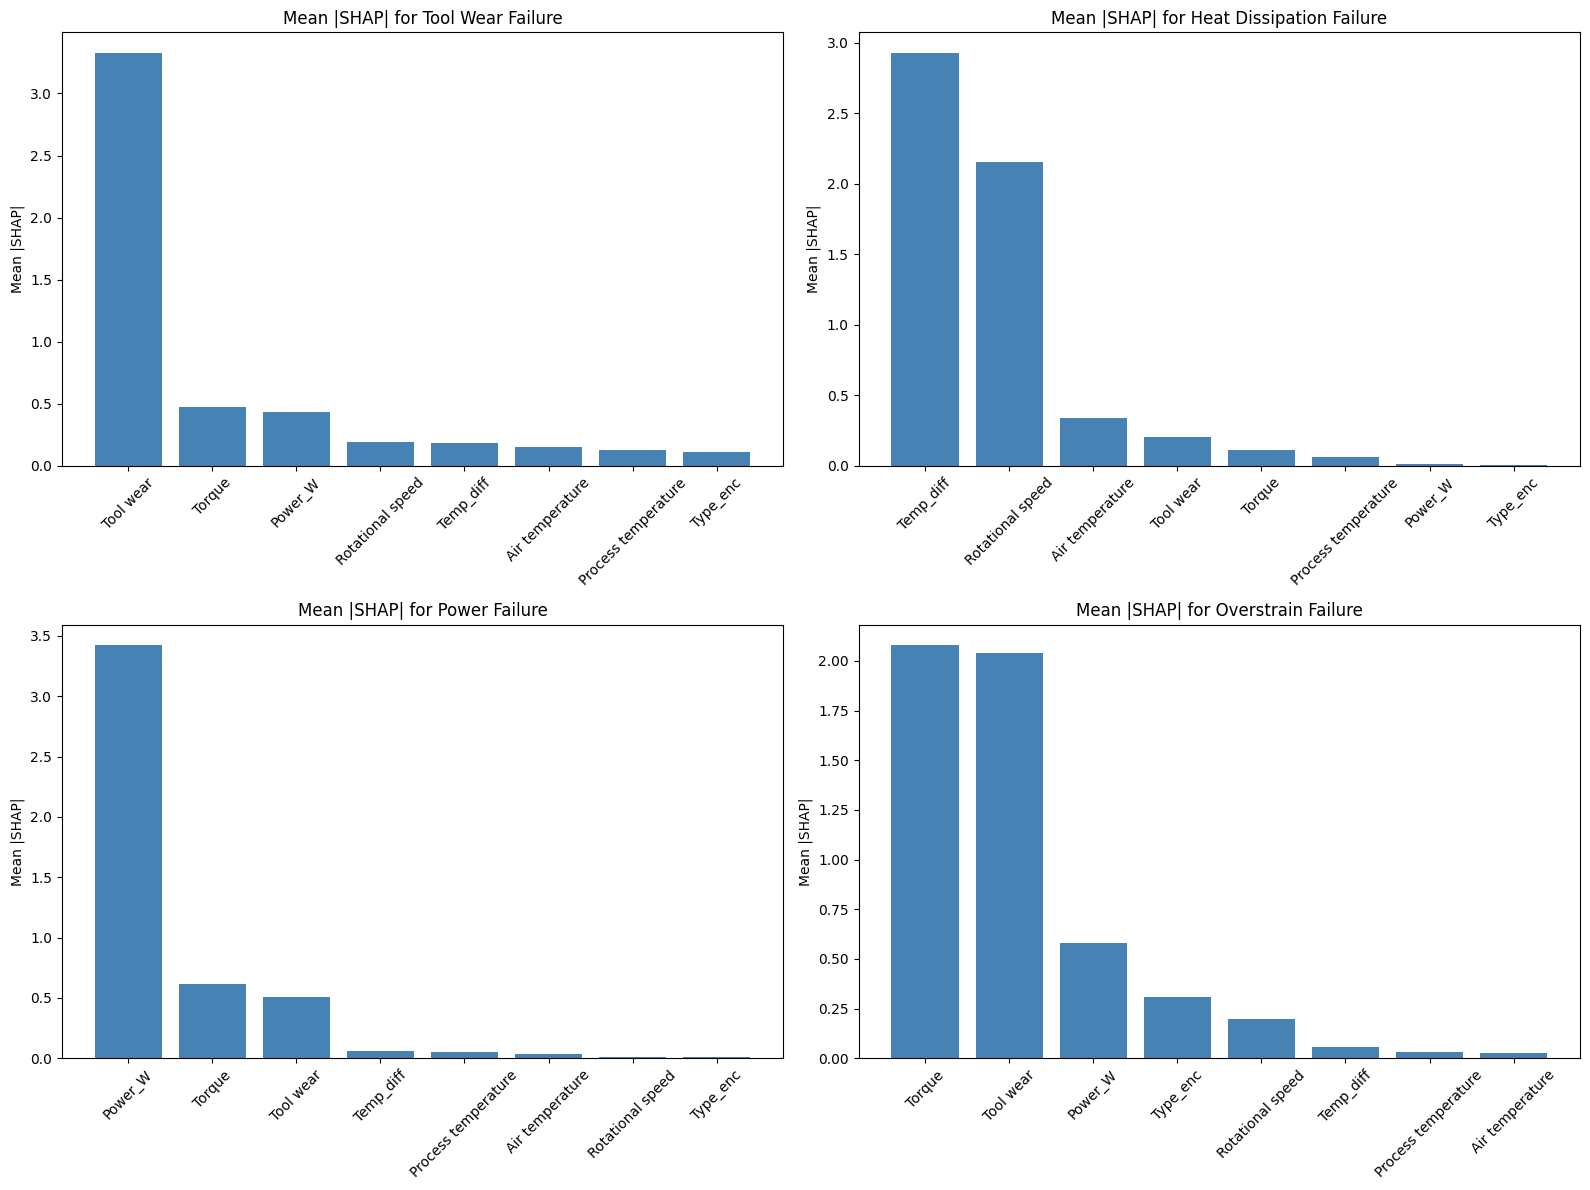

Top driver for TWF: Tool wear
Top driver for HDF: Temp_diff
Top driver for PWF: Power_W
Top driver for OSF: Torque


In [12]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
import shap
from IPython.display import Image, display

best_model = joblib.load('PredMaint_XGBoost.pkl')
X_shap = train[FEATURES]
explainer = shap.TreeExplainer(best_model)
raw_shap = explainer.shap_values(X_shap)
if isinstance(raw_shap, list):
    shap_3d = np.stack(raw_shap, axis=-1)
else:
    shap_3d = np.array(raw_shap)
    if shap_3d.ndim == 3 and shap_3d.shape[0] == len(CLASS_NAMES):
        shap_3d = np.transpose(shap_3d, (1, 2, 0))

failure_class_indices = [1, 2, 3, 4]
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()
shap_per_class = {}

for i, class_idx in enumerate(failure_class_indices):
    mean_abs = np.abs(shap_3d[:, :, class_idx]).mean(axis=0)
    order = np.argsort(mean_abs)[::-1]
    axes[i].bar([FEATURES[j] for j in order], mean_abs[order], color='steelblue')
    axes[i].set_title(f"Mean |SHAP| for {CLASS_DESCRIPTION[class_idx]}")
    axes[i].set_ylabel('Mean |SHAP|')
    axes[i].tick_params(axis='x', rotation=45)
    shap_per_class[CLASS_NAMES[class_idx]] = shap_3d[:, :, class_idx]

plt.tight_layout()
plt.savefig('shap_per_class.png', dpi=200, bbox_inches='tight')
plt.show()

#display(Image('shap_per_class.png'))

for class_idx in failure_class_indices:
    mean_abs = np.abs(shap_3d[:, :, class_idx]).mean(axis=0)
    top_feature = FEATURES[int(np.argmax(mean_abs))]
    print(f"Top driver for {CLASS_NAMES[class_idx]}: {top_feature}")


### **4.2** <font color=red>[2 marks]</font> Engineering insight

Answer in this markdown cell:

1. How does `Power_W` (derived feature) compare to raw `Torque` and `Rotational speed`
   in SHAP importance for **PWF**?
2. How does `Temp_diff` rank for **HDF** vs other failure types?
3. In 2?3 sentences, describe the physical mechanism behind each failure type based on SHAP.

Suggested structure for your actionable recommendation (used again in Section 5.1.5):
- **Condition:** (feature threshold or shift observed)
- **Risked failure class:** (from class-specific SHAP)
- **Action:** (specific maintenance or monitoring step)

**Your answer here:**

1. Power_W for PWF: ...
2. Temp_diff for HDF: ...
3. Physical mechanisms: ...


## **5. Conclusions** <font color=red>[5 marks]</font>

### **5.1** <font color=red>[5 marks]</font> Key findings

Write a structured conclusion (1 mark per point):

1. Which model won and why ? reference macro F1 numbers.
2. Why accuracy is misleading here ? operational cost implication.
3. TWF has F1 = 0.0 even after SMOTE + Optuna. Root cause and fix.
   - Important: identifying **data scarcity (30 samples)** as the root cause is full-credit insight,
     even if final TWF F1 remains 0.0.
4. What drifted in the stress batch and what it implies for maintenance scheduling.
5. One actionable recommendation for the engineering team based on SHAP.

## Conclusions

**1. Model selection:**
...

**2. Accuracy vs Macro F1:**
...

**3. The TWF problem:**
State this as a data engineering limitation first (rare class with only 30 real samples),
then propose what data should be collected next.

**4. Drift and maintenance schedule:**
...

**5. Actionable recommendation:**
Use this format: Condition -> Risked failure class -> Action.